# Oncology Trial Analytics Pipeline

## i3 Digital Health Technical Assignment

This notebook implements a reproducible workflow for profiling, transforming, and analyzing semi-structured oncology clinical trial metadata.

The workflow focuses on:

- data quality assessment
- schema normalization
- controlled vocabulary harmonization
- feature engineering
- operational success proxy modeling
- cohort-level analytical insights

The pipeline was designed to reflect practical healthcare analytics and clinical data engineering workflows commonly required for downstream cohort analysis.


# 1. Data Ingestion and Initial Profiling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re

pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_excel("../data/SampleDateExtract.xlsx")

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1000
Columns: 18


In [4]:
df.head()

,ID-datalake,nct_id,brief_title,official_title,phase,recruitment_status,start_date,completion_date,primary_completion_date,enrollment,enrollment_type,indications,interventions_drugs,drugs_datalake,main_technologies,specific_technologies,target_names,target_abbreviations
0,61690,NCT06669572,Lenvatinib and Pembrolizumab to Treat Patients...,"A Phase II, Multi-center, Single Arm Trial of ...",PHASE2,NOT_YET_RECRUITING,2026-01-13,2029-03-26,2029-03-26,35.0,ESTIMATED,"['Anorectal Cancer', 'Epithelial Neoplasm']","['Pembrolizumab', 'Lenvatinib']","['B936', 'B261']","[['Antibody'], ['Small Molecule']]","[['Monoclonal Antibody'], ['Small Molecule']]","[['Programmed cell death protein 1'], ['Fibrob...","[['PD-1'], ['FGFR1', 'FGFR2', 'FGFR3', 'FGFR4'..."
1,63117,NCT06883552,"An Open-label, Single-arm Clinical Study of St...","An Open-label, Single-arm Clinical Study of St...",PHASE2,NOT_YET_RECRUITING,2025-10-01,2026-10-01,2026-10-01,21.0,ESTIMATED,['Thoracic Neoplasm'],['Tislelizumab'],['B1344'],[['Antibody']],[['Monoclonal Antibody']],[['Programmed cell death protein 1']],[['PD-1']]
2,56177,NCT06366490,Safety and Immunogenicity of Innocell Autologo...,Phase 1 Study to Assess the Safety and Immunog...,PHASE1,NOT_YET_RECRUITING,2025-06-30,2026-06-30,2025-12-30,8.0,ESTIMATED,['Ovarian Cancer'],['Innocell'],['B11796'],[['Cancer Vaccine']],[['Whole Tumor Cell Vaccine']],[[]],[[]]
3,62820,NCT06835387,Study of NALIRIFOX in Advanced Unresectable Sm...,Phase II Study of NALIRIFOX (Nanoliposomal Iri...,PHASE2,RECRUITING,2025-05-31,2028-08-31,2027-08-31,36.0,ESTIMATED,['Small Intestinal Adenocarcinoma'],"['Irinotecan Sucrosofate', 'Dexamethasone', '5...","['B1128', 'B1229', 'B493', 'B226']","[['Small Molecule'], ['Small Molecule'], ['Sma...","[['Small Molecule'], ['Small Molecule'], ['Sma...","[['Glucocorticoid receptor'], ['DNA'], ['Thymi...","[['GR'], ['DNA'], ['TYMS'], []]"
4,63206,NCT06896188,"9-ING-41 Combined with Retifanlimab, Plus Modi...","A Phase Ib Study of 9-ING-41 (elraglusib), a G...",PHASE1,NOT_YET_RECRUITING,2025-05-31,2028-12-31,2027-05-31,12.0,ESTIMATED,['Pancreatic Cancer'],"['Retifanlimab', 'Oxaliplatin', 'Folinic acid'...","['B1394', 'B1229', 'B226', 'B1679', 'B493', 'B...","[['Antibody'], ['Small Molecule'], [], ['Small...","[['Monoclonal Antibody'], ['Small Molecule'], ...","[['Programmed cell death protein 1'], ['DNA'],...","[['PD-1'], ['DNA'], [], ['TOP1'], ['TYMS'], ['..."


## Schema Hygiene Audit

The raw dataset was inspected for:
- inconsistent naming conventions
- structural formatting issues
- downstream analytical usability


In [5]:
df.columns.tolist()

['ID-datalake',
 'nct_id',
 'brief_title',
 'official_title',
 'phase',
 'recruitment_status',
 'start_date',
 'completion_date',
 'primary_completion_date',
 'enrollment',
 'enrollment_type',
 'indications',
 'interventions_drugs',
 'drugs_datalake',
 'main_technologies',
 'specific_technologies',
 'target_names',
 'target_abbreviations']

In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("-", "_")
    .str.replace(" ", "_")
)

df.columns.tolist()


['id_datalake',
 'nct_id',
 'brief_title',
 'official_title',
 'phase',
 'recruitment_status',
 'start_date',
 'completion_date',
 'primary_completion_date',
 'enrollment',
 'enrollment_type',
 'indications',
 'interventions_drugs',
 'drugs_datalake',
 'main_technologies',
 'specific_technologies',
 'target_names',
 'target_abbreviations']

## Structured Data Quality Report

In [7]:
quality_report = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isnull().sum(),
    "missing_percent": (
        df.isnull().sum() / len(df) * 100
    ).round(2),
    "unique_values": df.nunique(),
    "unique_ratio": (
        df.nunique() / len(df)
    ).round(3),
    "sample_values": [
        df[col]
        .dropna()
        .astype(str)
        .unique()[:3]
        .tolist()
        for col in df.columns
    ]
})

quality_report.sort_values(
    by="missing_percent",
    ascending=False
)


,column,dtype,missing_values,missing_percent,unique_values,unique_ratio,sample_values
completion_date,completion_date,datetime64[ns],52,5.2,600,0.600,"[2029-03-26, 2026-10-01, 2026-06-30]"
primary_completion_date,primary_completion_date,datetime64[ns],51,5.1,610,0.610,"[2029-03-26, 2026-10-01, 2025-12-30]"
enrollment_type,enrollment_type,object,44,4.4,2,0.002,"[ESTIMATED, ACTUAL]"
phase,phase,object,40,4.0,7,0.007,"[PHASE2, PHASE1, PHASE3]"
enrollment,enrollment,float64,26,2.6,253,0.253,"[35.0, 21.0, 8.0]"
official_title,official_title,object,6,0.6,994,0.994,"[A Phase II, Multi-center, Single Arm Trial of..."
start_date,start_date,datetime64[ns],5,0.5,693,0.693,"[2026-01-13, 2025-10-01, 2025-06-30]"
id_datalake,id_datalake,int64,0,0.0,1000,1.000,"[61690, 63117, 56177]"
nct_id,nct_id,object,0,0.0,1000,1.000,"[NCT06669572, NCT06883552, NCT06366490]"
recruitment_status,recruitment_status,object,0,0.0,9,0.009,"[NOT_YET_RECRUITING, RECRUITING, WITHDRAWN]"


In [8]:
quality_report.to_csv(
    "../outputs/quality_report.csv",
    index=False
)


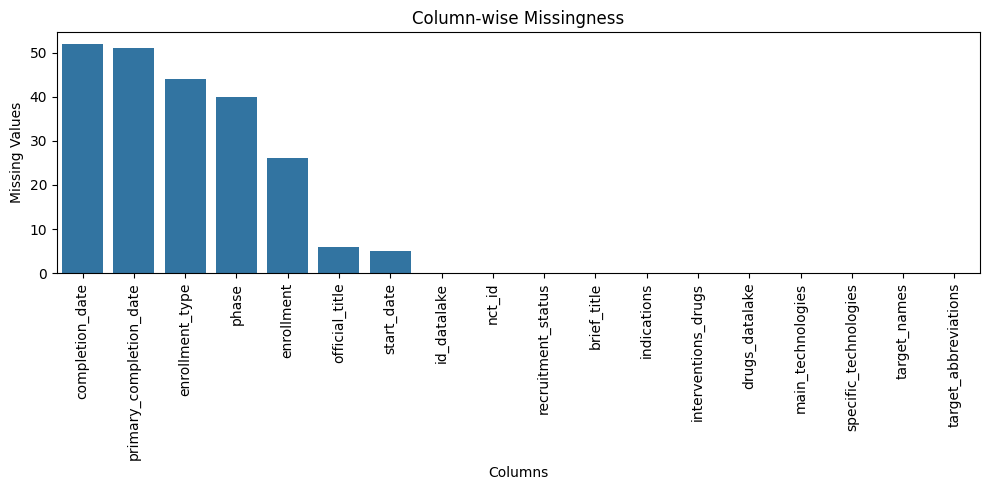

In [9]:
missingness = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=missingness.index,
    y=missingness.values
)

plt.xticks(rotation=90)

plt.ylabel("Missing Values")
plt.xlabel("Columns")

plt.title("Column-wise Missingness")

plt.tight_layout()

plt.savefig("../outputs/missingness_plot.png")

plt.show()


### Initial Observations

- Core operational trial metadata appeared highly complete.
- Missingness was concentrated primarily in completion-related temporal fields.
- The missing-value pattern likely reflects unresolved or ongoing trials rather than random corruption.


# 2. Controlled Vocabulary and Structural Integrity Assessment

In [10]:
controlled_vocab_columns = [
    "phase",
    "recruitment_status",
    "enrollment_type"
]

for col in controlled_vocab_columns:

    print(f"\n===== {col.upper()} =====\n")

    print(df[col].value_counts(dropna=False))



===== PHASE =====

phase
PHASE2           402
PHASE1           253
PHASE1/PHASE2    126
PHASE3           124
NaN               40
PHASE4            25
PHASE2/PHASE3     17
EARLY_PHASE1      13
Name: count, dtype: int64

===== RECRUITMENT_STATUS =====

recruitment_status
COMPLETED                  453
RECRUITING                 140
TERMINATED                 123
UNKNOWN                    121
ACTIVE_NOT_RECRUITING       76
NOT_YET_RECRUITING          41
WITHDRAWN                   40
SUSPENDED                    4
ENROLLING_BY_INVITATION      2
Name: count, dtype: int64

===== ENROLLMENT_TYPE =====

enrollment_type
ACTUAL       598
ESTIMATED    358
NaN           44
Name: count, dtype: int64


In [11]:
whitespace_issues = {}

for col in df.select_dtypes(include="object").columns:

    whitespace_count = (
        df[col]
        .dropna()
        .astype(str)
        .apply(lambda x: x != x.strip())
        .sum()
    )

    if whitespace_count > 0:
        whitespace_issues[col] = whitespace_count

whitespace_issues


{}

In [12]:
encoding_issues = {}

for col in df.columns:

    strange_values = []

    unique_values = (
        df[col]
        .dropna()
        .astype(str)
        .unique()
    )

    for value in unique_values:

        if re.search(r"[ÎÃÂ]", value):
            strange_values.append(value)

    if strange_values:
        encoding_issues[col] = strange_values[:5]

encoding_issues


{'brief_title': ['Neoadjuvant Toripalimab + Chemotherapy Â± Cetuximab in Locally Advanced Head and Neck Squamous Cell Carcinoma (Neo-ICT)',
  'Performance of EluciremÂ® in DSC-MRI Perfusion of Brain Gliomas',
  'A Clinical Study of TJ004309 With Atezolizumab (TECENTRIQÂ®) in Patients With Ovarian Cancer and Selected Solid Tumors',
  'Flavored, Oral Irinotecan VAL-413 (OrotecanÂ®) Given With Temozolomide for Treatment of Recurrent Pediatric Solid Tumors',
  'GFRÎ±4 CAR T Cells in MTC Patients'],
 'official_title': ['A Phase Ib Study of 9-ING-41 (elraglusib), a Glycogen Synthase Kinase 3-beta (GSK-3Î²) Inhibitor, Combined with Retifanlimab, a PD-1 Inhibitor, Plus Modified FOLFIRINOX As Frontline Therapy for Patients with Advanced Pancreatic Adenocarcinoma (RiLEY)',
  'Performance of EluciremÂ® (Gadopiclenol) in Dynamic Susceptibility Contrast Magnetic Resonance Imaging (DSC-MRI) Perfusion of Brain Gliomas Phase IIIb Clinical Trial',
  'A Phase 2 Study of 9-ING-41, a Glycogen Synthase Kin

In [13]:
duplicate_nct_ids = df["nct_id"].duplicated().sum()

print(f"Duplicate nct_id values: {duplicate_nct_ids}")


Duplicate nct_id values: 0


In [14]:
invalid_dates = df[
    df["completion_date"] < df["start_date"]
]

invalid_dates.shape[0]


0

In [15]:
df["trial_duration_days"] = (
    df["completion_date"] - df["start_date"]
).dt.days

df["start_year"] = (
    df["start_date"]
    .dt.year
)

df[
    [
        "nct_id",
        "start_date",
        "completion_date",
        "trial_duration_days",
        "start_year"
    ]
].head()


,nct_id,start_date,completion_date,trial_duration_days,start_year
0,NCT06669572,2026-01-13,2029-03-26,1168.0,2026.0
1,NCT06883552,2025-10-01,2026-10-01,365.0,2025.0
2,NCT06366490,2025-06-30,2026-06-30,365.0,2025.0
3,NCT06835387,2025-05-31,2028-08-31,1188.0,2025.0
4,NCT06896188,2025-05-31,2028-12-31,1310.0,2025.0


# 3. Analytical Schema Design and Normalization

## Multi-Valued Field Assessment

Several biological annotation fields contain nested multi-valued structures embedded within flat-file cells.

These structures require decomposition before cohort-level analytics.


In [16]:
multi_value_columns = [
    "interventions_drugs",
    "drugs_datalake",
    "main_technologies",
    "specific_technologies",
    "target_names",
    "target_abbreviations",
    "indications"
]

for col in multi_value_columns:

    print(f"\n===== {col} =====\n")

    print(df[col].iloc[0])



===== interventions_drugs =====

['Pembrolizumab', 'Lenvatinib']

===== drugs_datalake =====

['B936', 'B261']

===== main_technologies =====

[['Antibody'], ['Small Molecule']]

===== specific_technologies =====

[['Monoclonal Antibody'], ['Small Molecule']]

===== target_names =====

[['Programmed cell death protein 1'], ['Fibroblast growth factor receptor 1', 'Fibroblast growth factor receptor 2', 'Fibroblast growth factor receptor 3', 'Fibroblast growth factor receptor 4', 'Platelet-derived growth factor receptor alpha', 'Stem cell growth factor receptor', 'Tyrosine-protein kinase receptor RET', 'Vascular endothelial growth factor receptor 1', 'Vascular endothelial growth factor receptor 2', 'Vascular endothelial growth factor receptor 3']]

===== target_abbreviations =====

[['PD-1'], ['FGFR1', 'FGFR2', 'FGFR3', 'FGFR4', 'PDGFRÎ±', 'c-Kit', 'RET', 'VEGFR1', 'VEGFR2', 'VEGFR3']]

===== indications =====

['Anorectal Cancer', 'Epithelial Neoplasm']


In [17]:
for col in multi_value_columns:

    df[col] = df[col].apply(
        lambda x: ast.literal_eval(x)
        if isinstance(x, str)
        else x
    )


In [18]:
phase_mapping = {
    "EARLY_PHASE1": "PHASE1",
    "PHASE1/PHASE2": "PHASE1_2",
    "PHASE2/PHASE3": "PHASE2_3"
}

df["phase_standardized"] = (
    df["phase"]
    .replace(phase_mapping)
)

status_mapping = {
    "ACTIVE_NOT_RECRUITING": "ACTIVE",
    "NOT_YET_RECRUITING": "PLANNED",
    "ENROLLING_BY_INVITATION": "RECRUITING"
}

df["status_standardized"] = (
    df["recruitment_status"]
    .replace(status_mapping)
)


In [19]:
df["indications_standardized"] = (
    df["indications"]
    .apply(
        lambda x: [
            item.strip().title()
            for item in x
        ] if isinstance(x, list) else x
    )
)


In [20]:
phase_integer_mapping = {
    "PHASE1": 1,
    "PHASE1_2": 1.5,
    "PHASE2": 2,
    "PHASE2_3": 2.5,
    "PHASE3": 3,
    "PHASE4": 4
}

df["phase_numeric"] = (
    df["phase_standardized"]
    .map(phase_integer_mapping)
)


## Relational Mapping Tables

Nested biomedical relationships were decomposed into analytical mapping tables suitable for cohort-level analysis.


In [21]:
drug_table = df[
    [
        "nct_id",
        "interventions_drugs"
    ]
].explode("interventions_drugs")

technology_table = df[
    [
        "nct_id",
        "main_technologies"
    ]
].explode("main_technologies")

target_table = df[
    [
        "nct_id",
        "target_names"
    ]
].explode("target_names")

indication_table = df[
    [
        "nct_id",
        "indications_standardized"
    ]
].explode("indications_standardized")

drug_table.head()


,nct_id,interventions_drugs
0,NCT06669572,Pembrolizumab
0,NCT06669572,Lenvatinib
1,NCT06883552,Tislelizumab
2,NCT06366490,Innocell
3,NCT06835387,Irinotecan Sucrosofate


# 4. Operational Success Logic

## Defining an Operational Success Proxy

The dataset does not contain explicit therapeutic efficacy or regulatory outcome labels.

Therefore, a computable operational proxy was constructed using trial lifecycle metadata, particularly recruitment and completion status fields.

It is important to distinguish:
- operational trial progression
from
- true therapeutic or clinical success

A trial may complete operationally while failing to meet efficacy endpoints. The current framework therefore estimates operational execution outcomes rather than biological or regulatory success.


In [22]:
outcome_mapping = {

    "COMPLETED": "success_like",

    "TERMINATED": "failure_like",
    "WITHDRAWN": "failure_like",

    "RECRUITING": "ongoing",
    "ACTIVE": "ongoing",
    "PLANNED": "ongoing",

    "UNKNOWN": "ambiguous",
    "SUSPENDED": "ambiguous"
}

df["outcome_category"] = (
    df["status_standardized"]
    .map(outcome_mapping)
)

df["outcome_category"].value_counts(dropna=False)


outcome_category
success_like    453
ongoing         259
failure_like    163
ambiguous       125
Name: count, dtype: int64

In [23]:
binary_mapping = {
    "success_like": 1,
    "failure_like": 0
}

df["success_proxy"] = (
    df["outcome_category"]
    .map(binary_mapping)
)

df["success_proxy"].value_counts(dropna=False)


success_proxy
1.0    453
NaN    384
0.0    163
Name: count, dtype: int64

### Operational Outcome Interpretation

The constructed proxy should be interpreted as an estimate of operational trial progression rather than therapeutic efficacy.

Ongoing and ambiguous studies were excluded from binary estimation due to right-censoring and unresolved operational outcomes.


# 5. Stratified Cohort Success Analysis

## Success Rate by Clinical Phase

In [24]:
phase_success = (
    df.groupby("phase_standardized")["success_proxy"]
    .mean()
    .sort_values(ascending=False)
)

phase_success


phase_standardized
PHASE4      0.875000
PHASE3      0.802817
PHASE2_3    0.777778
PHASE1      0.759563
PHASE2      0.701299
PHASE1_2    0.675000
Name: success_proxy, dtype: float64

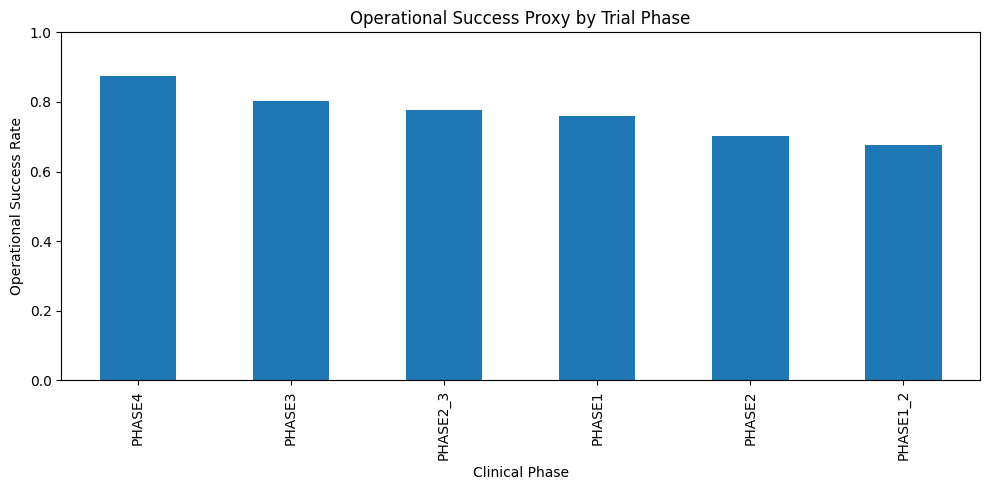

In [25]:
plt.figure(figsize=(10,5))

phase_success.plot(kind="bar")

plt.ylabel("Operational Success Rate")
plt.xlabel("Clinical Phase")
plt.title("Operational Success Proxy by Trial Phase")

plt.ylim(0,1)

plt.tight_layout()

plt.savefig("../outputs/phase_success.png")

plt.show()


### Phase-Level Interpretation

Later-stage trials demonstrated higher operational completion rates relative to earlier exploratory studies.

This pattern likely reflects:
- greater operational maturity
- selective progression through development stages
- survivorship bias among advanced programs


## Success Rate by Technology Type

In [26]:
technology_analysis = technology_table.merge(
    df[["nct_id", "success_proxy"]],
    on="nct_id",
    how="left"
)

# robust flattening function
def clean_nested_value(x):

    while isinstance(x, list):

        if len(x) == 0:
            return np.nan

        x = x[0]

    return str(x).strip()

# apply cleaning
technology_analysis["main_technologies"] = (
    technology_analysis["main_technologies"]
    .apply(clean_nested_value)
)

# remove invalid values
technology_analysis = technology_analysis[
    technology_analysis["main_technologies"].notna()
]

technology_analysis = technology_analysis[
    technology_analysis["main_technologies"] != ""
]

technology_counts = (
    technology_analysis["main_technologies"]
    .value_counts()
)

valid_technologies = technology_counts[
    technology_counts >= 10
].index

technology_success = (
    technology_analysis[
        technology_analysis["main_technologies"]
        .isin(valid_technologies)
    ]
    .groupby("main_technologies")["success_proxy"]
    .mean()
    .sort_values(ascending=False)
)

technology_success

main_technologies
Other Protein Therapy                               0.902439
Small Molecule                                      0.767857
Radiopharmaceutical Imaging                         0.750000
nan                                                 0.697674
Antibody                                            0.689655
Chimeric Antigen Receptor T-Cell Therapy (CAR-T)    0.666667
Engineered Protein Therapy                          0.666667
Antibody Drug Conjugate (ADC)                       0.375000
Name: success_proxy, dtype: float64

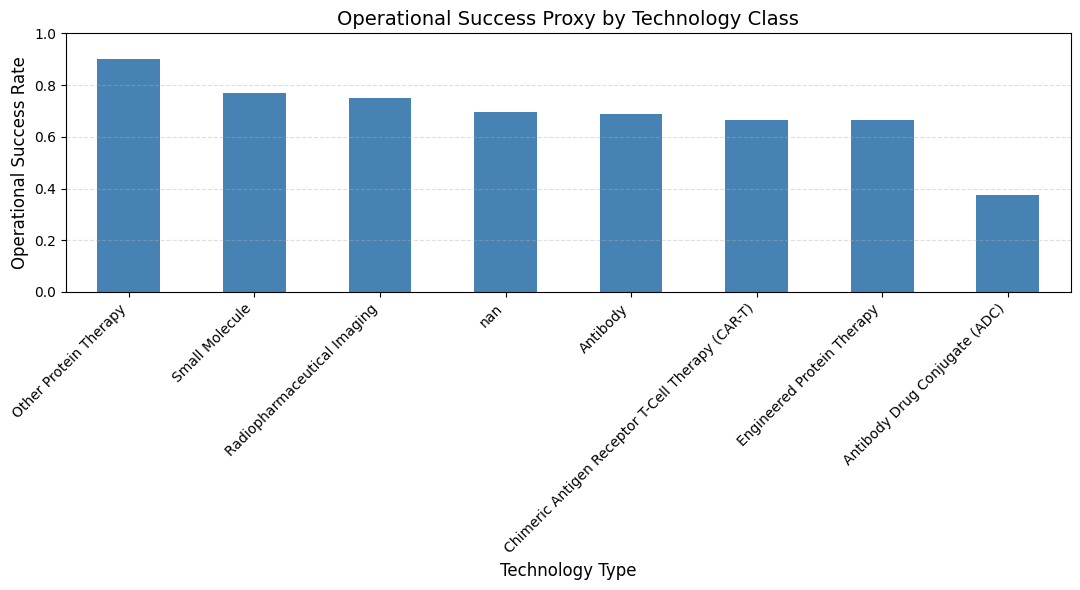

In [27]:
plt.figure(figsize=(11,6))

technology_success.plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel(
    "Operational Success Rate",
    fontsize=12
)

plt.xlabel(
    "Technology Type",
    fontsize=12
)

plt.title(
    "Operational Success Proxy by Technology Class",
    fontsize=14
)

plt.ylim(0,1)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "../outputs/technology_success.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Technology-Level Interpretation

Operational completion patterns varied across therapeutic technology classes.

Interpretation should be performed cautiously due to:
- unequal cohort sizes
- modality-specific development complexity
- potential temporal confounding


## Success Rate by Oncology Indication

In [28]:
indication_analysis = indication_table.merge(
    df[["nct_id", "success_proxy"]],
    on="nct_id",
    how="left"
)

indication_counts = (
    indication_analysis["indications_standardized"]
    .value_counts()
)

valid_indications = indication_counts[
    indication_counts >= 10
].index

indication_success = (
    indication_analysis[
        indication_analysis["indications_standardized"]
        .isin(valid_indications)
    ]
    .groupby("indications_standardized")["success_proxy"]
    .mean()
    .sort_values(ascending=False)
)

indication_success


indications_standardized
Anemia                                     1.000000
Breast Neoplasm                            1.000000
Glioma                                     1.000000
Neuroendocrine Tumors                      1.000000
Rectal Carcinoma                           1.000000
Male Reproductive System Neoplasm          0.923077
Female Reproductive System Neoplasm        0.900000
Leukemia                                   0.900000
Neoplasms                                  0.900000
Colon Carcinoma                            0.857143
Uveal Melanoma                             0.857143
Skin Melanoma                              0.846154
Cancer                                     0.842105
Brain Metastasis                           0.833333
Ovarian Cancer                             0.818182
Cervical Cancer                            0.818182
Connective And Soft Tissue Neoplasm        0.818182
Solid Tumors                               0.816327
Glioblastoma                           

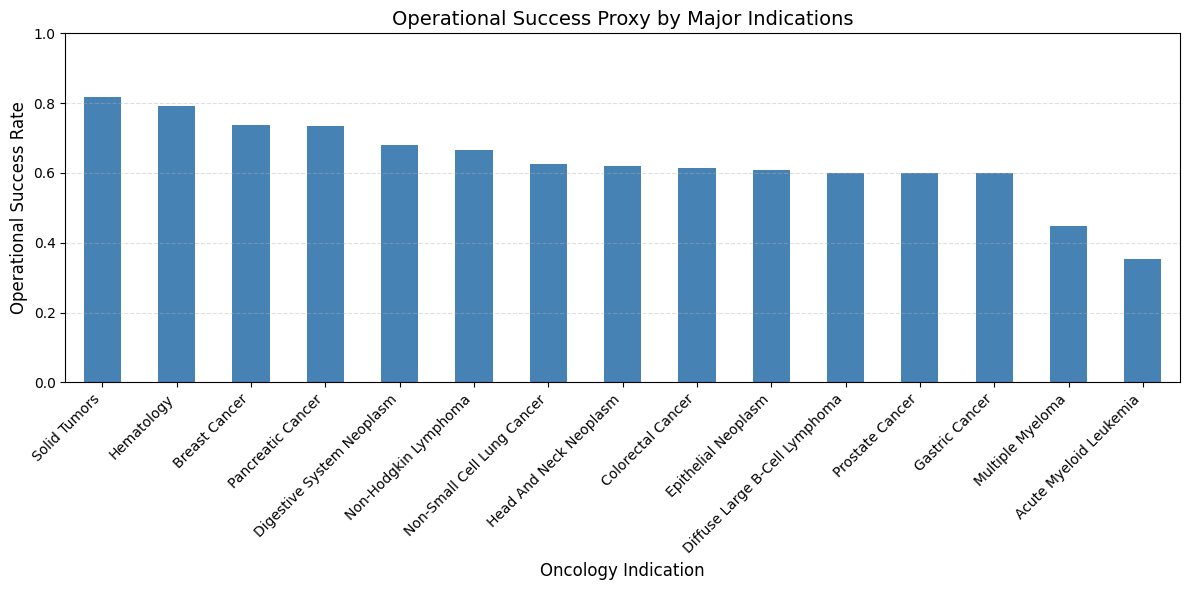

In [29]:
# select top indications by frequency
top_indications = (
    indication_analysis["indications_standardized"]
    .value_counts()
    .head(15)
    .index
)

filtered_indication_success = (
    indication_analysis[
        indication_analysis["indications_standardized"]
        .isin(top_indications)
    ]
    .groupby("indications_standardized")["success_proxy"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

filtered_indication_success.plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel(
    "Operational Success Rate",
    fontsize=12
)

plt.xlabel(
    "Oncology Indication",
    fontsize=12
)

plt.title(
    "Operational Success Proxy by Major Indications",
    fontsize=14
)

plt.ylim(0,1)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "../outputs/indication_success.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Indication-Level Interpretation

Operational success rates differed across oncology indications.

These differences may reflect:
- disease complexity
- recruitment feasibility
- therapeutic maturity
- cohort-size variability


## Indication × Phase Cohort Analysis

In [30]:
phase_indication_analysis = indication_table.merge(
    df[
        [
            "nct_id",
            "phase_standardized",
            "success_proxy"
        ]
    ],
    on="nct_id",
    how="left"
)

phase_indication_summary = (
    phase_indication_analysis
    .groupby(
        [
            "indications_standardized",
            "phase_standardized"
        ]
    )["success_proxy"]
    .agg(["mean", "count"])
    .reset_index()
)

phase_indication_summary = (
    phase_indication_summary[
        phase_indication_summary["count"] >= 5
    ]
)

phase_indication_summary.head(10)


,indications_standardized,phase_standardized,mean,count
11,Acute Lymphoblastic Leukemia,PHASE1,0.600000,5
13,Acute Lymphoblastic Leukemia,PHASE2,0.500000,6
18,Acute Myeloid Leukemia,PHASE1,0.444444,9
20,Acute Myeloid Leukemia,PHASE2,0.300000,20
30,Adult T-Cell Leukemia/Lymphoma,PHASE1_2,0.000000,5
55,Anemia,PHASE3,1.000000,5
91,Breast Cancer,PHASE1,0.653846,26
92,Breast Cancer,PHASE1_2,0.727273,11
93,Breast Cancer,PHASE2,0.838710,31
101,Breast Neoplasm,PHASE2,1.000000,6


### Multi-Dimensional Cohort Interpretation

Stratified analyses revealed substantial heterogeneity across:
- disease indications
- development stages
- therapeutic technology classes

Small-cohort estimates were filtered to reduce unstable success-rate interpretations.


# 6. Limitations and Analytical Caveats

## Key Limitations

This framework estimates operational trial progression rather than true therapeutic efficacy.

The dataset does not include:
- efficacy endpoints
- progression-free survival
- overall survival
- adverse event burden
- regulatory approvals

Additional limitations include:
- right-censoring of ongoing studies
- heterogeneous disease ontology granularity
- incomplete modality harmonization
- small-strata instability
- inability to assess biological response quality


# 7. Proposed Analytical Schema

## Suggested Normalized Analytical Structure

| Table | Purpose |
|---|---|
| trials | core operational trial metadata |
| drug_table | trial-to-drug many-to-many mapping |
| technology_table | trial-to-technology mapping |
| target_table | trial-to-target mapping |
| indication_table | trial-to-indication mapping |

The resulting structure conceptually aligns with analytical normalization principles commonly used in healthcare and clinical analytics workflows.


# 8. Conclusion

This workflow demonstrates how semi-structured oncology trial metadata can be transformed into a reproducible analytical framework suitable for cohort-level operational analytics.

The pipeline incorporated:
- structured profiling
- controlled vocabulary harmonization
- normalization of nested biomedical relationships
- operational outcome modeling
- stratified cohort analysis

While the constructed success proxy does not estimate therapeutic efficacy directly, it provides a scalable operational framework for exploratory clinical trial analytics.
